# Fluxes


In [1]:
source /export/ciao/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./


CIAO configuration is complete... 
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3


In [2]:
/bin/rm -rf 6436 repro
download_chandra_obsid 6436

chandra_repro 6436 out=`pwd`/repro clob+


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  readme   ascii      11 Kb  ####################          < 1 s  414.2 kb/s
  oif      fits       25 Kb  ####################          < 1 s  361.0 kb/s
  vv       pdf        39 Kb  ####################          < 1 s  297.2 kb/s
  cntr_img fits       67 Kb  ####################          < 1 s  6650.8 kb/s
  cntr_img jpg       412 Kb  ####################          < 1 s  6247.0 kb/s
  evt2     fits       10 Mb  ####################          < 1 s  18895.0 kb/s
  full_img fits       72 Kb  ####################          < 1 s  7121.6 kb/s
  full_img jpg        60 Kb  ####################          < 1 s  2364.2 kb/s
  bpix     fits       62 Kb  ####################          < 1 s  3112.7 kb/s
  fov      fits        6 Kb  ####################          < 1 s  898.0 kb/s
  eph1     fits      283 Kb  ####################          < 1 s  

## Quick Look

In [3]:
dmcopy "repro/acisf06436_repro_evt2.fits[ccd_id=0:3]" acis_i.fits clob+
fluximage acis_i.fits fimg/ bands=broad,csc bin=4 clob+

Running fluximage
Version: 12 September 2016

Using CSC ACIS broad science energy band.
Using CSC ACIS soft science energy band.
Using CSC ACIS medium science energy band.
Using CSC ACIS hard science energy band.
Aspect solution repro/pcadf268499655N002_asol1.fits found.
Bad-pixel file repro/acisf06436_repro_bpix1.fits found.
Mask file repro/acisf06436_000N002_msk1.fits found.

The output images will have 566 by 565 pixels, pixel size of 1.968 arcsec,
    and cover x=2888.5:5152.5:4,y=2996.5:5256.5:4.

Running tasks in parallel with 4 processors.
Creating aspect histograms for obsid 6436
Creating 16 instrument maps for obsid 6436
Creating 16 exposure maps for obsid 6436
Combining 4 exposure maps for 4 bands (obsid 6436)
Thresholding data for obsid 6436
Exposure-correcting 4 images for obsid 6436

The following files were created:

 The clipped counts images are:
     fimg/broad_thresh.img
     fimg/soft_thresh.img
     fimg/medium_thresh.img
     fimg/hard_thresh.img

 The clipped expo

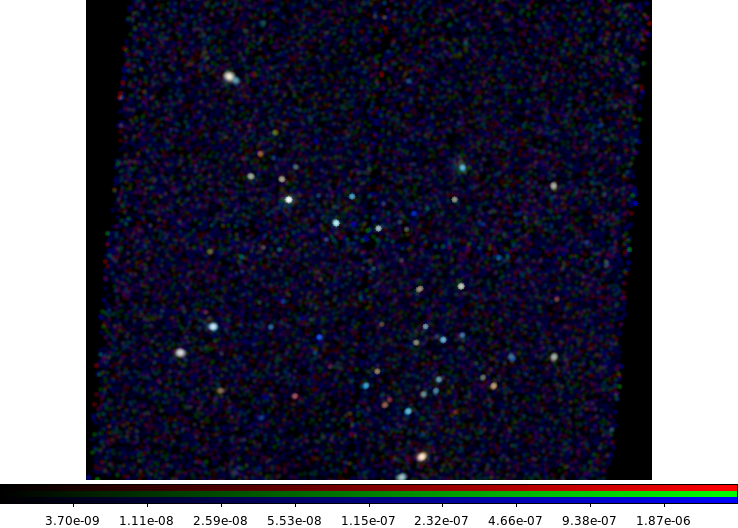

In [4]:
ds9 -rgb -red fimg/soft_flux.img \
         -green fimg/medium_flux.img \
         -blue fimg/hard_flux.img \
         -rgb lock scale yes -rgb lock smooth yes -log -smooth \
         -saveimage png ds9_01.png -quit
        
display < ds9_01.png


## A single Source

In [5]:
dmstat "fimg/broad_flux.img[sky=circle(3397,3781,20)]" cen+ verb=0
xc=`stk_read_num ')dmstat.out_cntrd_phys' 1 echo+`
yc=`stk_read_num ')dmstat.out_cntrd_phys' 2 echo+`
echo "Centroid: $xc $yc"


Centroid: 3397.3308642 3781.5695287


In [6]:
punlearn dmcoords
dmcoords fimg/broad_flux.img opt=sky x=$xc y=$yc
ra=`pget dmcoords ra`
dec=`pget dmcoords dec`
echo "$ra $dec"

03:29:29.250 +31:18:34.73


### Now run `srcflux`

In [7]:
punlearn srcflux
srcflux repro/acisf06436_repro_evt2.fits "$ra $dec" single/run1 clob+

srcflux
          infile = repro/acisf06436_repro_evt2.fits
             pos = 03:29:29.250 +31:18:34.73
         outroot = single/run1
           bands = broad
          srcreg = 
          bkgreg = 
         bkgresp = yes
       psfmethod = ideal
         psffile = 
            conf = 0.9
         binsize = 1
         rmffile = 
         arffile = 
           model = xspowerlaw.pow1
       paramvals = pow1.PhoIndex=2.0
        absmodel = xsphabs.abs1
       absparams = abs1.nH=%GAL%
           abund = angr
         fovfile = 
        asolfile = 
         mskfile = 
        bpixfile = 
         dtffile = 
         ecffile = CALDB
        parallel = yes
           nproc = INDEF
          tmpdir = ./
         clobber = yes
         verbose = 1
            mode = ql

Processing OBI 000
Extracting counts
Setting Ideal PSF : alpha=1 , beta=0
Getting net rate and confidence limits
Getting model independent fluxes 
Getting model fluxes 
Getting photon fluxes 
Running tasks in parallel with 4

In [8]:
dmlist single/run1_broad.flux"[cols net_rate_aper,net_flux_aper,net_mflux_aper,net_umflux_aper]" data,clean

#  NET_RATE_APER        NET_FLUX_APER        NET_MFLUX_APER       NET_UMFLUX_APER
           0.03979610      5.172731323E-13      4.463530576E-13      5.525290524E-13


In [9]:
dmlist single/run1_broad.flux"[cols net_flux_aper,net_flux_aper_lo,net_flux_aper_hi]" data,clean

#  NET_FLUX_APER        NET_FLUX_APER_LO     NET_FLUX_APER_HI
      5.172731323E-13      4.949541187E-13      5.397286258E-13


In [10]:
dmlist single/run1_broad.flux"[cols shape,r,area,bg_area]" data,clean

#  SHAPE              R[2]                                     AREA                 BG_AREA
 Circle                        10.28780                    0               332.50           7979.43750


In [11]:
dmlist single/run1_broad.flux"[cols theta,phi]" data,clean

#  THETA                PHI
         6.2879507976       298.9574365002


In [12]:
dmlist single/run1_broad.flux"[cols theta,phi]" cols

 
--------------------------------------------------------------------------------
Columns for Table Block HISTOGRAM
--------------------------------------------------------------------------------
 
ColNo  Name                 Unit        Type             Range
   1   THETA                arcmin       Real8          -Inf:+Inf            Off axis angle
   2   PHI                  deg          Real8          -Inf:+Inf            Azimuth angle


In [13]:
dmlist single/run1_broad.flux"[cols psffrac,bg_psffrac]" data,clean

#  PSFFRAC              BG_PSFFRAC
                  1.0                    0


In [14]:
ls -1 single/run1_*

single/run1_0001.arf
single/run1_0001.pi
single/run1_0001.rmf
single/run1_0001_bkg.pi
single/run1_0001_bkgreg.fits
single/run1_0001_broad_flux.img
single/run1_0001_broad_rates.prob
single/run1_0001_broad_thresh.expmap
single/run1_0001_broad_thresh.img
single/run1_0001_grp.pi
single/run1_0001_nopsf.arf
single/run1_0001_srcreg.fits
single/run1_broad.flux
single/run1_summary.txt


read ARF file single/run1_0001.arf
read RMF file single/run1_0001.rmf
read ARF (background) file single/run1_0001.arf
read RMF (background) file single/run1_0001.rmf
read background file single/run1_0001_bkg.pi
4.23057608949e-09
4.384556677e-13


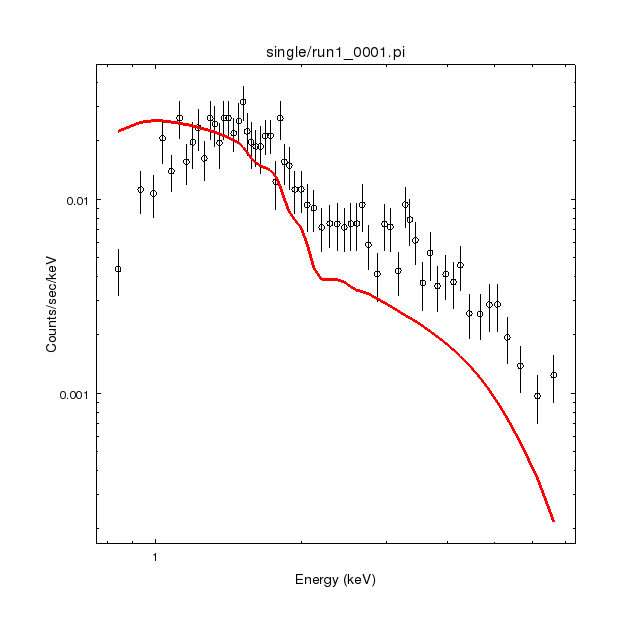

In [15]:
cat << EOM > s1.py
load_data("single/run1_0001.pi")
subtract()
group_counts(20)
ignore(None, 0.6)
ignore(7,None)
set_source(xsphabs.abs1 * xspowerlaw.pow1)
abs1.nh = 0
pow1.phoindex = 2
print(calc_energy_flux(0.5, 7))
f0 = calc_energy_flux(0.5, 7)
pow1.norm.val *= 4.384556677E-13 / f0
print(calc_energy_flux(0.5, 7))
plot_fit()
log_scale()
print_window("sherpa_01.png","export.clobber=True")
quit()
EOM

sherpa -b s1.py
display < sherpa_01.png


## Correct for Absorption

In [16]:
ra_1=`echo "${ra}" | tr ":" " "`
dec_1=`echo "${dec}" | tr ":" " "`
prop_colden d nrao eval $ra_1 $dec_1

Looking for /export/ciao-4.9/config/jcm_data/nrao.fits
------------------------------------------------------------------------------------------
Input coords:  03 29 29.25 +31 18 34.73
Target RA,Dec (B1950): 03 26 23.595 +31 08 17.581   (l,b):158.397653   -20.466863
Density integrated from   -550.000 to    550.000 km/s
Hydrogen density (10^20 cm**(-2)):  14.64
------------------------------------------------------------------------------------------


In [17]:
pset srcflux model=xspowerlaw.pow1 paramvals="pow1.phoindex=2"
pset srcflux absmodel=xsphabs.abs1 absparams="abs1.nh=0.1464"
srcflux repro/acisf06436_repro_evt2.fits "$ra $dec" single/run2 clob+


srcflux
          infile = repro/acisf06436_repro_evt2.fits
             pos = 03:29:29.250 +31:18:34.73
         outroot = single/run2
           bands = broad
          srcreg = 
          bkgreg = 
         bkgresp = yes
       psfmethod = ideal
         psffile = 
            conf = 0.9
         binsize = 1
         rmffile = 
         arffile = 
           model = xspowerlaw.pow1
       paramvals = pow1.phoindex=2
        absmodel = xsphabs.abs1
       absparams = abs1.nh=0.1464
           abund = angr
         fovfile = 
        asolfile = 
         mskfile = 
        bpixfile = 
         dtffile = 
         ecffile = CALDB
        parallel = yes
           nproc = INDEF
          tmpdir = ./
         clobber = yes
         verbose = 1
            mode = ql

Processing OBI 000
Extracting counts
Setting Ideal PSF : alpha=1 , beta=0
Getting net rate and confidence limits
Getting model independent fluxes 
Getting model fluxes 
Getting photon fluxes 
Running tasks in parallel with 4 

In [18]:
dmlist single/run\*_broad.flux"[cols net_rate_aper,net_flux_aper,net_mflux_aper,net_umflux_aper]" data,clean

#  NET_RATE_APER        NET_FLUX_APER        NET_MFLUX_APER       NET_UMFLUX_APER
           0.03979610      5.172731323E-13      4.463530576E-13      5.525290524E-13
#  NET_RATE_APER        NET_FLUX_APER        NET_MFLUX_APER       NET_UMFLUX_APER
           0.03979610      5.172731323E-13      4.463530576E-13      5.525290524E-13
#  NET_RATE_APER        NET_FLUX_APER        NET_MFLUX_APER       NET_UMFLUX_APER
           0.04578380      5.951015419E-13      5.135111008E-13      6.356622792E-13
#  NET_RATE_APER        NET_FLUX_APER        NET_MFLUX_APER       NET_UMFLUX_APER
           0.04584270      6.777902034E-13      5.141717232E-13      6.364800468E-13
#  NET_RATE_APER        NET_FLUX_APER        NET_MFLUX_APER       NET_UMFLUX_APER
           0.04318340      5.648197017E-13      4.858996168E-13      6.014583952E-13


## PSF correction

In [19]:
srcflux repro/acisf06436_repro_evt2.fits "$ra $dec" single/run3 psfmethod=quick clob+

srcflux
          infile = repro/acisf06436_repro_evt2.fits
             pos = 03:29:29.250 +31:18:34.73
         outroot = single/run3
           bands = broad
          srcreg = 
          bkgreg = 
         bkgresp = yes
       psfmethod = quick
         psffile = 
            conf = 0.9
         binsize = 1
         rmffile = 
         arffile = 
           model = xspowerlaw.pow1
       paramvals = pow1.phoindex=2
        absmodel = xsphabs.abs1
       absparams = abs1.nh=0.1464
           abund = angr
         fovfile = 
        asolfile = 
         mskfile = 
        bpixfile = 
         dtffile = 
         ecffile = CALDB
        parallel = yes
           nproc = INDEF
          tmpdir = ./
         clobber = yes
         verbose = 1
            mode = ql

Processing OBI 000
Extracting counts
Getting net rate and confidence limits
Getting model independent fluxes 
Getting model fluxes 
Getting photon fluxes 
Running tasks in parallel with 4 processors.
Running eff2evt for singl

In [20]:
dmlist "single/run3_broad.flux[cols shape,r,area,bg_area]" data,clean

#  SHAPE              R[2]                                     AREA                 BG_AREA
 Circle                        10.28780                    0               332.50           7979.43750


In [21]:
dmlist "single/run3_broad.flux[cols psffrac,bg_psffrac]" data,clean

#  PSFFRAC              BG_PSFFRAC
     0.86921826932448                    0


In [22]:
dmlist "single/run\*_broad.flux[cols net_rate_aper,net_flux_aper,net_mflux_aper,net_umflux_aper]" data,clean

#  NET_RATE_APER        NET_FLUX_APER        NET_MFLUX_APER       NET_UMFLUX_APER
           0.03979610      5.172731323E-13      4.463530576E-13      5.525290524E-13
#  NET_RATE_APER        NET_FLUX_APER        NET_MFLUX_APER       NET_UMFLUX_APER
           0.03979610      5.172731323E-13      4.463530576E-13      5.525290524E-13
#  NET_RATE_APER        NET_FLUX_APER        NET_MFLUX_APER       NET_UMFLUX_APER
           0.04578380      5.951015419E-13      5.135111008E-13      6.356622792E-13
#  NET_RATE_APER        NET_FLUX_APER        NET_MFLUX_APER       NET_UMFLUX_APER
           0.04584270      6.777902034E-13      5.141717232E-13      6.364800468E-13
#  NET_RATE_APER        NET_FLUX_APER        NET_MFLUX_APER       NET_UMFLUX_APER
           0.04318340      5.648197017E-13      4.858996168E-13      6.014583952E-13


In [23]:
srcflux repro/acisf06436_repro_evt2.fits "$ra $dec" single/run4 psfmethod=arfcorr clob+

srcflux
          infile = repro/acisf06436_repro_evt2.fits
             pos = 03:29:29.250 +31:18:34.73
         outroot = single/run4
           bands = broad
          srcreg = 
          bkgreg = 
         bkgresp = yes
       psfmethod = arfcorr
         psffile = 
            conf = 0.9
         binsize = 1
         rmffile = 
         arffile = 
           model = xspowerlaw.pow1
       paramvals = pow1.phoindex=2
        absmodel = xsphabs.abs1
       absparams = abs1.nh=0.1464
           abund = angr
         fovfile = 
        asolfile = 
         mskfile = 
        bpixfile = 
         dtffile = 
         ecffile = CALDB
        parallel = yes
           nproc = INDEF
          tmpdir = ./
         clobber = yes
         verbose = 1
            mode = ql

Processing OBI 000
Extracting counts
Making PSF models 
Getting PSF fraction by running arfcorr 1
Combining PSF fractions together
Getting net rate and confidence limits
Getting model independent fluxes 
Getting model fluxe

In [24]:
dmlist "single/run4_broad.flux[cols psffrac,bg_psffrac]" data,clean

#  PSFFRAC              BG_PSFFRAC
     0.87266341940279     0.10948754332054


In [25]:
dmlist "single/run4_broad.flux[cols net_rate_aper,net_flux_aper,net_mflux_aper,net_umflux_aper]" data,clean

#  NET_RATE_APER        NET_FLUX_APER        NET_MFLUX_APER       NET_UMFLUX_APER
           0.04584270      6.777902034E-13      5.141717232E-13      6.364800468E-13


## Specify region

In [26]:
cat << EOM > src.reg
circle(3397,3782,20)
EOM

cat << EOM > bg.reg
annulus(3397,3782,30,60)
EOM

In [27]:
srcflux repro/acisf06436_repro_evt2.fits "$ra $dec" single/run5 src=src.reg bkgreg=bg.reg psfmethod=arfcorr clob+

srcflux
          infile = repro/acisf06436_repro_evt2.fits
             pos = 03:29:29.250 +31:18:34.73
         outroot = single/run5
           bands = broad
          srcreg = src.reg
          bkgreg = bg.reg
         bkgresp = yes
       psfmethod = arfcorr
         psffile = 
            conf = 0.9
         binsize = 1
         rmffile = 
         arffile = 
           model = xspowerlaw.pow1
       paramvals = pow1.phoindex=2
        absmodel = xsphabs.abs1
       absparams = abs1.nh=0.1464
           abund = angr
         fovfile = 
        asolfile = 
         mskfile = 
        bpixfile = 
         dtffile = 
         ecffile = CALDB
        parallel = yes
           nproc = INDEF
          tmpdir = ./
         clobber = yes
         verbose = 1
            mode = ql

Processing OBI 000
Extracting counts
Making PSF models 
Getting PSF fraction by running arfcorr 1
Combining PSF fractions together
Getting net rate and confidence limits
Getting model independent fluxes 
Gettin

In [28]:
dmlist single/run5_broad.flux"[cols psffrac,bg_psffrac]" data,clean

#  PSFFRAC              BG_PSFFRAC
     0.97144798019988     0.00315935080555


## Upper limits

In [29]:
punlearn srcflux
srcflux repro/acisf06436_repro_evt2.fits "3:29:01.24 +31:19:30.72" ulim/src clob+

srcflux
          infile = repro/acisf06436_repro_evt2.fits
             pos = 3:29:01.24 +31:19:30.72
         outroot = ulim/src
           bands = broad
          srcreg = 
          bkgreg = 
         bkgresp = yes
       psfmethod = ideal
         psffile = 
            conf = 0.9
         binsize = 1
         rmffile = 
         arffile = 
           model = xspowerlaw.pow1
       paramvals = pow1.PhoIndex=2.0
        absmodel = xsphabs.abs1
       absparams = abs1.nH=%GAL%
           abund = angr
         fovfile = 
        asolfile = 
         mskfile = 
        bpixfile = 
         dtffile = 
         ecffile = CALDB
        parallel = yes
           nproc = INDEF
          tmpdir = ./
         clobber = yes
         verbose = 1
            mode = ql

Processing OBI 000
Extracting counts
Setting Ideal PSF : alpha=1 , beta=0
Getting net rate and confidence limits
Getting model independent fluxes 
Getting model fluxes 
Getting photon fluxes 
Running tasks in parallel with 4 proc

In [30]:
dmlist ulim/src_broad.flux"[cols upper_limit]" data,clean

#  UPPER_LIMIT
  TRUE 


In [31]:
dmlist ulim/src_broad.flux"[cols net_rate_aper,net_flux_aper,net_mflux_aper]" data,clean

#  NET_RATE_APER        NET_FLUX_APER        NET_MFLUX_APER
                    0                  NaN                    0


In [32]:
dmlist ulim/src_broad.flux"[cols net_rate_aper_hi,net_flux_aper_hi,net_mflux_aper_hi]" data,clean

#  NET_RATE_APER_HI     NET_FLUX_APER_HI     NET_MFLUX_APER_HI
          6.31259E-05                  NaN      6.159067811E-16


## Off Chip

In [36]:
punlearn srcflux
srcflux repro/acisf06436_repro_evt2.fits "3:29:48 +31:27:20" offchip/run1 clob+

srcflux
          infile = repro/acisf06436_repro_evt2.fits
             pos = 3:29:48 +31:27:20
         outroot = offchip/run1
           bands = broad
          srcreg = 
          bkgreg = 
         bkgresp = yes
       psfmethod = ideal
         psffile = 
            conf = 0.9
         binsize = 1
         rmffile = 
         arffile = 
           model = xspowerlaw.pow1
       paramvals = pow1.PhoIndex=2.0
        absmodel = xsphabs.abs1
       absparams = abs1.nH=%GAL%
           abund = angr
         fovfile = 
        asolfile = 
         mskfile = 
        bpixfile = 
         dtffile = 
         ecffile = CALDB
        parallel = yes
           nproc = INDEF
          tmpdir = ./
         clobber = yes
         verbose = 1
            mode = ql

Processing OBI 000
Extracting counts
Setting Ideal PSF : alpha=1 , beta=0
Getting net rate and confidence limits
Getting model independent fluxes 
Getting model fluxes 
Getting photon fluxes 
Running tasks in parallel with 4 proces

In [37]:
dmlist "offchip/run1_broad.flux[cols inside_fov,upper_limit,net_rate_aper,net_rate_aper_lo,net_rate_aper_hi]" data,clean


Failed to open virtual file offchip/run1_broad.flux[cols inside_fov,upper_limit,net_rate_aper,net_rate_aper_lo,net_rate_aper_hi]
# DMLIST (CIAO 4.9): Column select syntax: unknown column net_rate_aper_hi


In [38]:
dmlist "offchip/run1_broad.flux[cols shape,x,y,r,area,bg_area]" data,clean

#  SHAPE              sky(X,Y)                                 R[2]                                     AREA                 BG_AREA
 Point                                 0                    0                    0                    0                    0           5117.43750


In [40]:
srcflux repro/acisf06436_repro_evt2.fits "3:29:43.5 +31:26:35" overlap/run1 clob+

srcflux
          infile = repro/acisf06436_repro_evt2.fits
             pos = 3:29:43.5 +31:26:35
         outroot = overlap/run1
           bands = broad
          srcreg = 
          bkgreg = 
         bkgresp = yes
       psfmethod = ideal
         psffile = 
            conf = 0.9
         binsize = 1
         rmffile = 
         arffile = 
           model = xspowerlaw.pow1
       paramvals = pow1.PhoIndex=2.0
        absmodel = xsphabs.abs1
       absparams = abs1.nH=%GAL%
           abund = angr
         fovfile = 
        asolfile = 
         mskfile = 
        bpixfile = 
         dtffile = 
         ecffile = CALDB
        parallel = yes
           nproc = INDEF
          tmpdir = ./
         clobber = yes
         verbose = 1
            mode = ql

Processing OBI 000
Extracting counts
Setting Ideal PSF : alpha=1 , beta=0
Getting net rate and confidence limits
Getting model independent fluxes 
Getting model fluxes 
Getting photon fluxes 
Running tasks in parallel with 4 proc

In [41]:
dmlist "overlap/run1_broad.flux[cols shape,x,y,r,area,bg_area]" data,clean

#  SHAPE              sky(X,Y)                                 R[2]                                     AREA                 BG_AREA
 Circle                               3027.670      4758.190            23.92080                    0           1550.81250          24399.81250


In [42]:
dmlist "overlap/run1_broad.flux[cols inside_fov,upper_limit,near_chip_edge]" data,clean

#  INSIDE_FOV UPPER_LIMIT NEAR_CHIP_EDGE
  TRUE   TRUE   TRUE 


In [43]:
dmlist "overlap/run1_broad.flux[cols net_rate_aper,net_rate_aper_lo,net_rate_aper_hi]" data,clean

#  NET_RATE_APER        NET_RATE_APER_LO     NET_RATE_APER_HI
                    0                  NaN           0.00010986


In [44]:
dmlist single/run1_broad.flux blocks

 
--------------------------------------------------------------------------------
Dataset: single/run1_broad.flux
--------------------------------------------------------------------------------
 
     Block Name                          Type         Dimensions
--------------------------------------------------------------------------------
Block    1: PRIMARY                        Null        
Block    2: HISTOGRAM                      Table        63 cols x 1        rows
Block    3: GTI3                           Table         2 cols x 1        rows
Block    4: GTI6                           Table         2 cols x 1        rows
Block    5: GTI7                           Table         2 cols x 1        rows
Block    6: GTI2                           Table         2 cols x 1        rows
Block    7: GTI1                           Table         2 cols x 1        rows
Block    8: GTI0                           Table         2 cols x 3        rows


In [45]:
dmlist single/run1_broad.flux cols

 
--------------------------------------------------------------------------------
Columns for Table Block HISTOGRAM
--------------------------------------------------------------------------------
 
ColNo  Name                 Unit        Type             Range
   1   sky(X,Y)             pixel        Real8          -Inf:+Inf            Position
   2   EQPOS(RA,Dec)        deg          Real8          -360.0:      360.0   Position
   3   SHAPE                             String[16]                          Region shape type
   4   R[2]                 pixel        Real8(2)       -Inf:+Inf            Radius
   5   ROTANG[2]            pixel        Real8(2)       -Inf:+Inf            Angle
   6   COMPONENT                         Int2           -                    Component number
   7   COUNTS               count        Real8          -Inf:+Inf            Counts
   8   ERR_COUNTS           count        Real8          -Inf:+Inf            Error on counts
   9   AREA                 pixe

## Source List

In [46]:
mkdir -p csc
search_csc ngc1333 10 csc/ngc1333.tsv clob+

search_csc
             pos = ngc1333
          radius = 10
         outfile = csc/ngc1333.tsv
         radunit = arcmin
         columns = INDEF
     sensitivity = no
        download = none
            root = ./
           bands = broad,wide
       filetypes = regevt,pha,arf,rmf,lc,psf,regexp
         catalog = csc1
         verbose = 1
         clobber = yes
            mode = ql


221 rows returned by query
99 Different Master Source(s).
3 Different Observation(s).

name                	ra          	dec         	sepn	obsid	
CXO J032810.6+312105	 52.04420   	 31.35154   	9.6'	 6437	
CXO J032810.6+312105	 52.04420   	 31.35154   	9.6'	 6436	
CXO J032810.6+312105	 52.04420   	 31.35154   	9.6'	  642	
CXO J032828.8+312037	 52.12018   	 31.34361   	5.8'	 6436	
CXO J032829.7+312512	 52.12398   	 31.42010   	6.2'	 6437	
CXO J032829.7+312512	 52.12398   	 31.42010   	6.2'	 6436	
CXO J032831.8+312120	 52.13271   	 31.35570   	5.1'	 6437	
CXO J032831.8+312120	 52.13271   	 31.35570   	5.1'	 

In [47]:
dmcopy csc/ngc1333.tsv"[opt kernel=text/tsv][cols ra,dec]" csc.fits clob+
dmlist csc.fits cols

 
--------------------------------------------------------------------------------
Columns for Table Block ngc1333.tsv
--------------------------------------------------------------------------------
 
ColNo  Name                 Unit        Type             Range
   1   ra                   deg          Real4          -Inf:+Inf            Source position, ICRS right ascension
   2   dec                  deg          Real4          -Inf:+Inf            Source position, ICRS declination


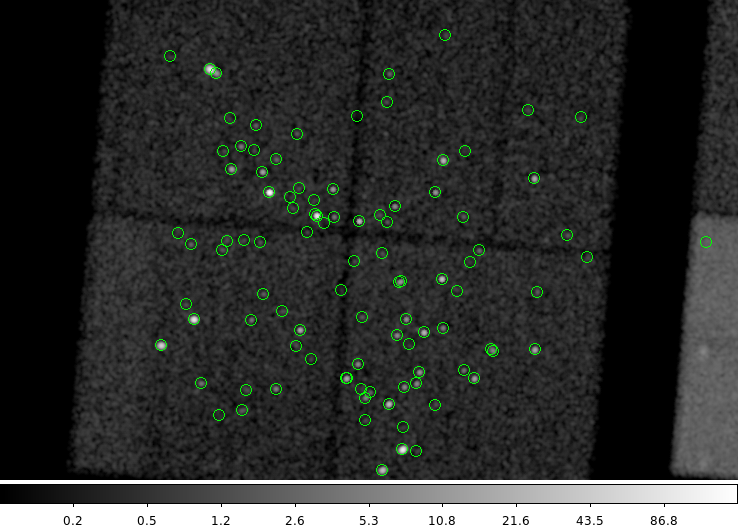

In [48]:
ds9 repro/acisf06436_repro_evt2.fits \
  -bin factor 4 -scale log -smooth \
  -catalog import tsv csc/ngc1333.tsv \
  -saveimage png ds9_02.png -quit

display < ds9_02.png

## Run wavdetect

In [49]:
mkpsfmap fimg/broad_thresh.img fimg/broad_thresh.psfmap 1.49 ecf=0.393 clob+


In [50]:
dmlist fimg/broad_thresh.psfmap header,clean,raw | grep BUNIT

BUNIT        = arcsec               / Units after BSCALE applied


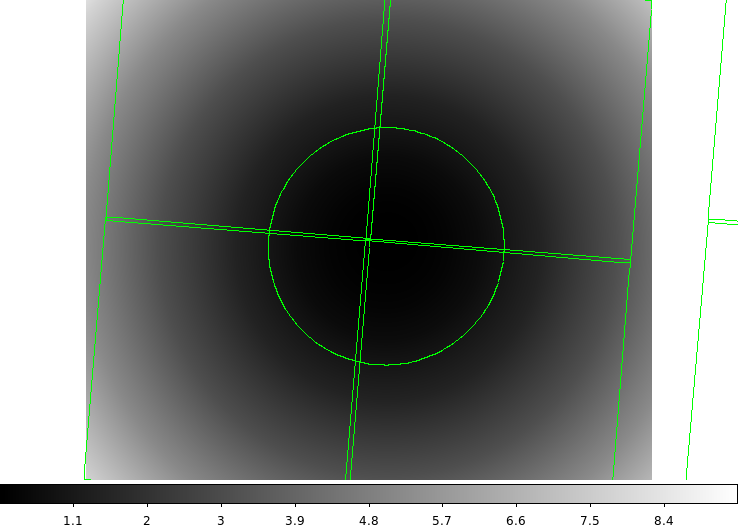

In [51]:
ds9 fimg/broad_thresh.psfmap -region repro/acisf06436_000N002_fov1.fits \
         -contour yes -contour levels "1" \
         -saveimage png ds9_03.png -quit

display < ds9_03.png

In [52]:
mkdir -p wav
punlearn wavdetect
pset wavdetect psffile=fimg/broad_thresh.psfmap
pset wavdetect expfile=fimg/broad_thresh.expmap
pset wavdetect regfile=wav/src.reg
pset wavdetect scales="2 4 8 16"
wavdetect fimg/broad_thresh.img wav/src.fits wav/src.scell wav/src.img wav/src.nbkg mode=h clobber=yes
dmlist wav/src.fits counts

81      


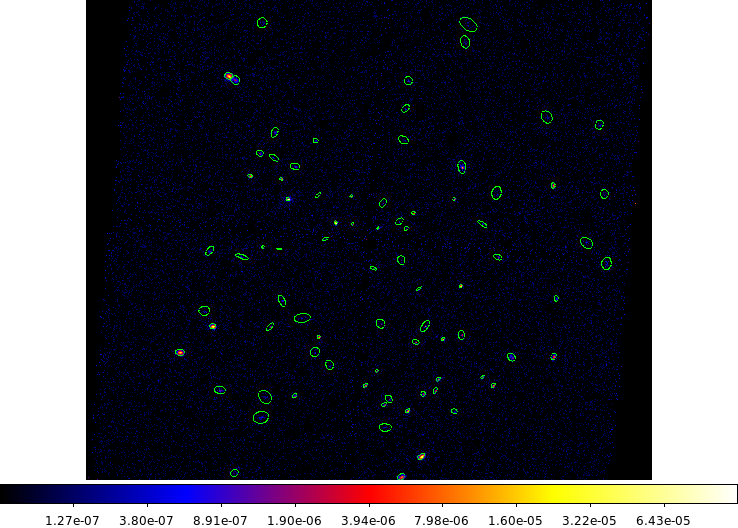

In [53]:
ds9 fimg/broad_flux.img -region wav/src.fits -log -cmap b \
  -saveimage png ds9_05.png -quit

display < ds9_05.png 

In [54]:
mkdir -p sources
punlearn roi
pset roi group=exclude bkgfactor=1
pset roi outsrcfile="sources/src%02d.fits"
pset roi targetbkg=target
roi wav/src.fits "region(repro/acisf06436_000N002_fov1.fits)" clob+ mode=h

In [55]:
ls -1 sources/src*fits | wc -l

81


In [56]:
dmlist sources/src01.fits blocks

 
--------------------------------------------------------------------------------
Dataset: sources/src01.fits
--------------------------------------------------------------------------------
 
     Block Name                          Type         Dimensions
--------------------------------------------------------------------------------
Block    1: PRIMARY                        Null        
Block    2: SRCREG                         Table         5 cols x 1        rows
Block    3: BKGREG                         Table         5 cols x 2        rows


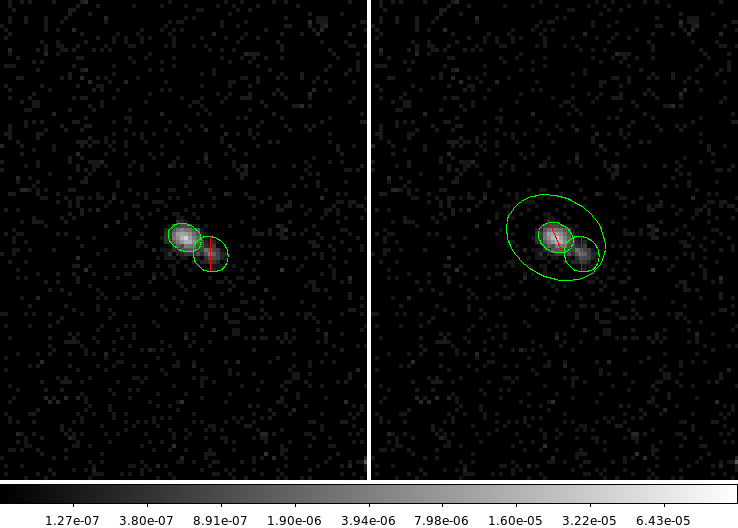

In [57]:
ds9 fimg/broad_flux.img -log -region sources/src75.fits \
     -pan to 3460 4780 -zoom 4 fimg/broad_flux.img -log \
     -region "sources/src75.fits[bkgreg]" -pan to 3460 4780 \
     -saveimage png ds9_06.png -quit
 
display < ds9_06.png


In [58]:
splitroi sources/src\*fits sources/wav 

In [59]:
ls -1 sources/wav*reg

sources/wav.bg.reg
sources/wav.src.reg


## Multiple Sources

### Using catalog

In [60]:
punlearn srcflux
pset srcflux model=xspowerlaw.pow1 paramvals="pow1.phoindex=2"
pset srcflux absmodel=xsphabs.abs1 absparams="abs1.nh=0.1464"
srcflux repro/acisf06436_repro_evt2.fits csc.fits"[#row=1,7,10,210,222]" multiple-csc/run clob+

srcflux
          infile = repro/acisf06436_repro_evt2.fits
             pos = csc.fits[#row=1,7,10,210,222]
         outroot = multiple-csc/run
           bands = broad
          srcreg = 
          bkgreg = 
         bkgresp = yes
       psfmethod = ideal
         psffile = 
            conf = 0.9
         binsize = 1
         rmffile = 
         arffile = 
           model = xspowerlaw.pow1
       paramvals = pow1.phoindex=2
        absmodel = xsphabs.abs1
       absparams = abs1.nh=0.1464
           abund = angr
         fovfile = 
        asolfile = 
         mskfile = 
        bpixfile = 
         dtffile = 
         ecffile = CALDB
        parallel = yes
           nproc = INDEF
          tmpdir = ./
         clobber = yes
         verbose = 1
            mode = ql

Processing OBI 000
Extracting counts
Setting Ideal PSF : alpha=1 , beta=0
Getting net rate and confidence limits
Getting model independent fluxes 
Getting model fluxes 
Getting photon fluxes 
Running tasks in paralle

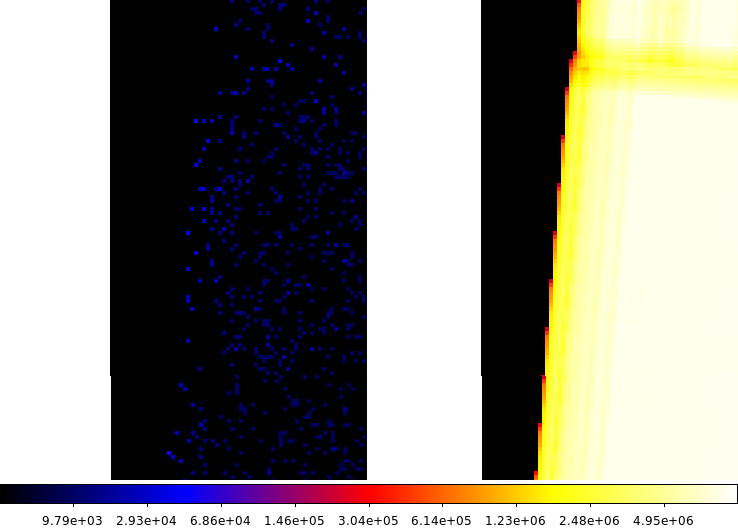

In [61]:
ds9 fimg/broad_flux.img -log -cmap b fimg/broad_thresh.expmap \
         -pan to 3:29:46 31:20:39 wcs fk5 -zoom 4 -match frame wcs \
         -region load all multiple-csc/run_broad.flux \
         -saveimage png ds9_07.png -quit
display < ds9_07.png

In [62]:
dmlist multiple-csc/run_broad.flux"[cols near_chip_edge,inside_fov,upper_limit]" data,clean

#  NEAR_CHIP_EDGE INSIDE_FOV UPPER_LIMIT
  FALSE  TRUE   FALSE
  FALSE  TRUE   FALSE
  FALSE  TRUE   FALSE
  FALSE  TRUE   FALSE


In [63]:
dmlist "multiple-csc/run_broad.flux[cols component,psffrac,bg_psffrac]" data,clean

#  COMPONENT  PSFFRAC              BG_PSFFRAC
          1                  1.0                    0
          2                  1.0                    0
          3                  1.0                    0
          4                  1.0                    0


In [64]:
 dmlist "multiple-csc/run_broad.flux[cols net_rate_aper,net_flux_aper,net_mflux_aper,net_umflux_aper]" data,clean

#  NET_RATE_APER        NET_FLUX_APER        NET_MFLUX_APER       NET_UMFLUX_APER
          0.001030660      1.205648829E-14      9.670270516E-15      1.197008524E-14
          0.000477685      9.030284359E-15       5.45420733E-15       6.75159979E-15
          0.000590679      4.143298574E-15      6.877275597E-15      8.513456427E-15
           0.03982470      5.175255379E-13      4.465543611E-13      5.528066607E-13


In [65]:
dmlist "multiple-csc/run_broad.flux[cols net_rate_aper,net_rate_aper_lo,net_rate_aper_hi]" data,clean

#  NET_RATE_APER        NET_RATE_APER_LO     NET_RATE_APER_HI
          0.001030660          0.000670746          0.001441990
          0.000477685          0.000293669          0.000712117
          0.000590679          0.000392889          0.000839598
           0.03982470           0.03810710           0.04155290


In [66]:
dmlist "multiple-csc/run_broad.flux[cols net_umflux_aper,net_umflux_aper_lo,net_umflux_aper_hi]" data,clean

#  NET_UMFLUX_APER      NET_UMFLUX_APER_LO   NET_UMFLUX_APER_HI
      1.197008524E-14      7.790044044E-15      1.674727186E-14
       6.75159979E-15      4.150717646E-15      1.006506168E-14
      8.513456427E-15      5.662709157E-15      1.210112597E-14
      5.528066607E-13      5.289646551E-13      5.767958049E-13


In [67]:
dmlist "multiple-csc/run_broad.flux[component=4][cols x,y,r,net_rate_aper,net_rate_aper_lo,net_rate_aper_hi]" data,clean

#  sky(X,Y)                                 R[2]                                     NET_RATE_APER        NET_RATE_APER_LO     NET_RATE_APER_HI
                   3397.380      3781.510            10.28740                    0           0.03982470           0.03810710           0.04155290


In [68]:
dmlist "single/run2_broad.flux[cols x,y,r,net_rate_aper,net_rate_aper_lo,net_rate_aper_hi]" data,clean

#  sky(X,Y)                                 R[2]                                     NET_RATE_APER        NET_RATE_APER_LO     NET_RATE_APER_HI
                   3397.340      3781.560            10.28780                    0           0.03979610            0.0380790           0.04152370


### Using source and region fiels

In [69]:
punlearn srcflux
pset srcflux model=xspowerlaw.pow1 paramvals="pow1.phoindex=2"
pset srcflux absmodel=xsphabs.abs1 absparams="abs1.nh=0.1464"
pset srcflux psfmethod=arfcorr
pset srcflux srcreg=@-sources/wav.src.reg
pset srcflux bkgreg=@-sources/wav.bg.reg
srcflux repro/acisf06436_repro_evt2.fits wav/src.fits multiple-wav/run clob+ mode=h

srcflux
          infile = repro/acisf06436_repro_evt2.fits
             pos = wav/src.fits
         outroot = multiple-wav/run
           bands = broad
          srcreg = @-sources/wav.src.reg
          bkgreg = @-sources/wav.bg.reg
         bkgresp = yes
       psfmethod = arfcorr
         psffile = 
            conf = 0.9
         binsize = 1
         rmffile = 
         arffile = 
           model = xspowerlaw.pow1
       paramvals = pow1.phoindex=2
        absmodel = xsphabs.abs1
       absparams = abs1.nh=0.1464
           abund = angr
         fovfile = 
        asolfile = 
         mskfile = 
        bpixfile = 
         dtffile = 
         ecffile = CALDB
        parallel = yes
           nproc = INDEF
          tmpdir = ./
         clobber = yes
         verbose = 1
            mode = h

Processing OBI 000
Extracting counts
Making PSF models 
Getting PSF fraction by running arfcorr 2
Getting PSF fraction by running arfcorr 3
Getting PSF fraction by running arfcorr 26
Getting 

In [70]:
dmlist "multiple-wav/run_broad.flux[inside_fov=false||upper_limit=true]" counts

0       


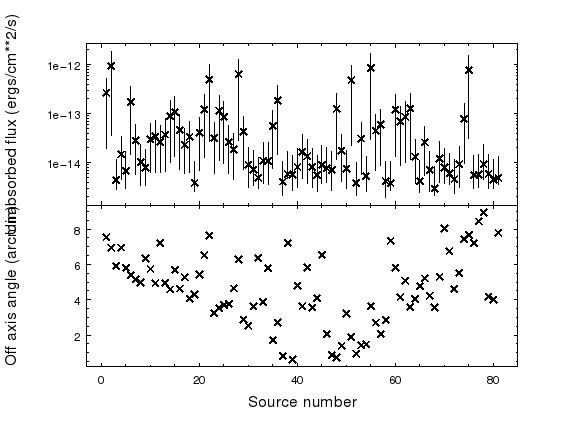

In [71]:
cat << EOM > c1.py
cr = read_file("multiple-wav/run_broad.flux")
cpt = cr.get_column("COMPONENT").values
umflux = cr.get_column("NET_UMFLUX_APER").values
umflux_lo = cr.get_column("NET_UMFLUX_APER_LO").values
umflux_hi = cr.get_column("NET_UMFLUX_APER_HI").values
add_window(8, 6, 'inches')
add_curve(cpt, umflux, [umflux_lo, umflux_hi], ['line.style', 'noline'])
log_scale(Y_AXIS)
umflux_units = cr.get_column("NET_UMFLUX_APER").unit
set_plot_ylabel("Unabsorbed flux ({})".format(umflux_units))
set_yaxis(['offset.perpendicular', 70, 'label.size', 16])
hide_axis('ax1')
split(2, 1, 0)
theta = cr.get_column("THETA").values
theta_units = cr.get_column("THETA").unit
add_curve(cpt, theta, ['line.style', 'noline'])
set_plot_ylabel("Off axis angle ({})".format(theta_units))
set_yaxis(['offset.perpendicular', 70, 'label.size', 16])
set_plot_xlabel("Source number")
set_xaxis(['label.size', 16])
print_window("chips_02.png","export.clobber=True")
quit()
EOM

chips -b c1.py
display < chips_02.png


# Cleanup

In [ ]:
for d in */*.flux
do
  to=`echo $d | tr "/" "_"`
  cp -fv ${d} ${to}
done

/bin/rm -rf 6436 csc fimg multiple-csc multiple-wav offchip overlap repro single sources ulim wav
